# EDA 08: Genomic Signatures

## Purpose

Genomic signatures describe the overall state of a cancer genome rather than one specific gene. They tell us whether DNA repair looks faulty, whether chromosome copies are abnormal, and whether large parts of the genome have been gained, lost, or duplicated.

These measurements help interpret mutation and copy-number features. They are context and possible confounders, not direct evidence that two genes interact.

## Decisions inherited from mutation, CRISPR, and copy-number EDA

- Mutation absence is meaningful only in DNA-assayed models.
- Copy number remains continuous; loss/gain thresholds are sensitivity rules.
- High copy number must be interpreted relative to ploidy and whole-genome duplication.
- Mutation burden, copy-number burden, and CRISPR QC remain visible context.
- Genomic instability must not become a hidden biological score for a gene pair.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', context='notebook')

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data' / 'depmap_24Q4'

PATHS={'master':DATA/'architecture'/'model_master.csv','model_signatures':DATA/'derived'/'signatures_model.csv','default_signatures':DATA/'derived'/'signatures_default_dna_model.csv'}
master=pd.read_csv(PATHS['master'],low_memory=False)
signatures=pd.read_csv(PATHS['model_signatures'],low_memory=False)
default_signatures=pd.read_csv(PATHS['default_signatures'],low_memory=False)
print(signatures.shape, default_signatures.shape)
display(signatures.head())

(1929, 7) (1929, 7)


,model_id,MSIScore,Ploidy,LoHFraction,WGD,CIN,Aneuploidy
0,ACH-000839,3.68,3.346668,0.102563,1.0,0.461073,20.0
1,ACH-000041,2.21,3.229258,0.110841,1.0,0.511092,19.0
2,ACH-002046,2.87,4.961658,0.213305,1.0,0.763144,36.0
3,ACH-002048,2.48,2.535103,0.221135,0.0,0.558663,28.0
4,ACH-000042,2.07,NaN,NaN,NaN,NaN,NaN


## Column dictionary

| Column | Plain-language biological meaning | Use in this project |
| --- | --- | --- |
| `model_id` | DepMap cell-line identifier. | Only automatic model join key. |
| `MSIScore` | Evidence of errors in repeated DNA caused by faulty mismatch repair. | DNA-repair context; release-specific continuous score. |
| `Ploidy` | Average number of chromosome copies across the genome. | Background for interpreting absolute gene copy number. |
| `LoHFraction` | Fraction of the genome with loss of heterozygosity, where one parental DNA version has been lost. | Genome-wide loss/repair context. |
| `WGD` | Whole-genome duplication indicator. | Explains globally elevated copy numbers. |
| `CIN` | Chromosomal-instability measure. | Context for widespread chromosome gains/losses. |
| `Aneuploidy` | Summary count/measure of chromosome-arm copy abnormalities. | Genome-wide copy-number disruption context. |

These are model-level summaries. They do not identify which individual gene is mutated or amplified.

## 1. Route equality, grain, and coverage

The release supplies signatures directly by model and through default DNA profiles. We compare them exactly so we know they describe the same model-level result.

In [2]:
left=signatures.sort_values('model_id').reset_index(drop=True)
right=default_signatures.sort_values('model_id').reset_index(drop=True)
comparison=(left.eq(right)|(left.isna()&right.isna()))
audit=pd.DataFrame([{'model_rows':len(signatures),'unique_models':signatures['model_id'].nunique(),'duplicate_model_ids':int(signatures['model_id'].duplicated().sum()),'models_not_in_master':len(set(signatures['model_id'])-set(master['model_id'])),'cell_values_different_between_routes':int((~comparison).sum().sum())}])
display(audit)
assert signatures['model_id'].is_unique and audit.loc[0,'cell_values_different_between_routes']==0

,model_rows,unique_models,duplicate_model_ids,models_not_in_master,cell_values_different_between_routes
0,1929,1929,0,0,0


### What this means for the project

The two routes agree exactly, so we can use the simpler model-level table without losing information or counting multiple DNA profiles as separate cell lines.

## 2. Distributions, missingness, and review flags

We inspect the scale of each signature. Extreme values are marked for review and sensitivity analysis, not automatically removed.

,missing_n,missing_pct,unique
model_id,0,0.000000,1929
MSIScore,0,0.000000,583
Ploidy,322,16.692587,1607
LoHFraction,322,16.692587,1603
WGD,322,16.692587,2
CIN,322,16.692587,1606
Aneuploidy,322,16.692587,40


,count,mean,std,min,25%,50%,75%,max
MSIScore,1929.0,6.112851,16.134656,0.300000,1.350000,2.130000,3.150000,93.220000
Ploidy,1607.0,2.993404,0.809795,1.672836,2.162989,2.973875,3.588661,4.994777
LoHFraction,1607.0,0.212615,0.161725,0.000000,0.077494,0.190249,0.319888,0.929901
CIN,1607.0,0.466489,0.244081,0.000000,0.260919,0.539070,0.664229,0.859347
Aneuploidy,1607.0,16.666459,10.009063,0.000000,8.000000,19.000000,24.000000,39.000000
WGD,1607.0,0.660859,0.473565,0.000000,0.000000,1.000000,1.000000,1.000000


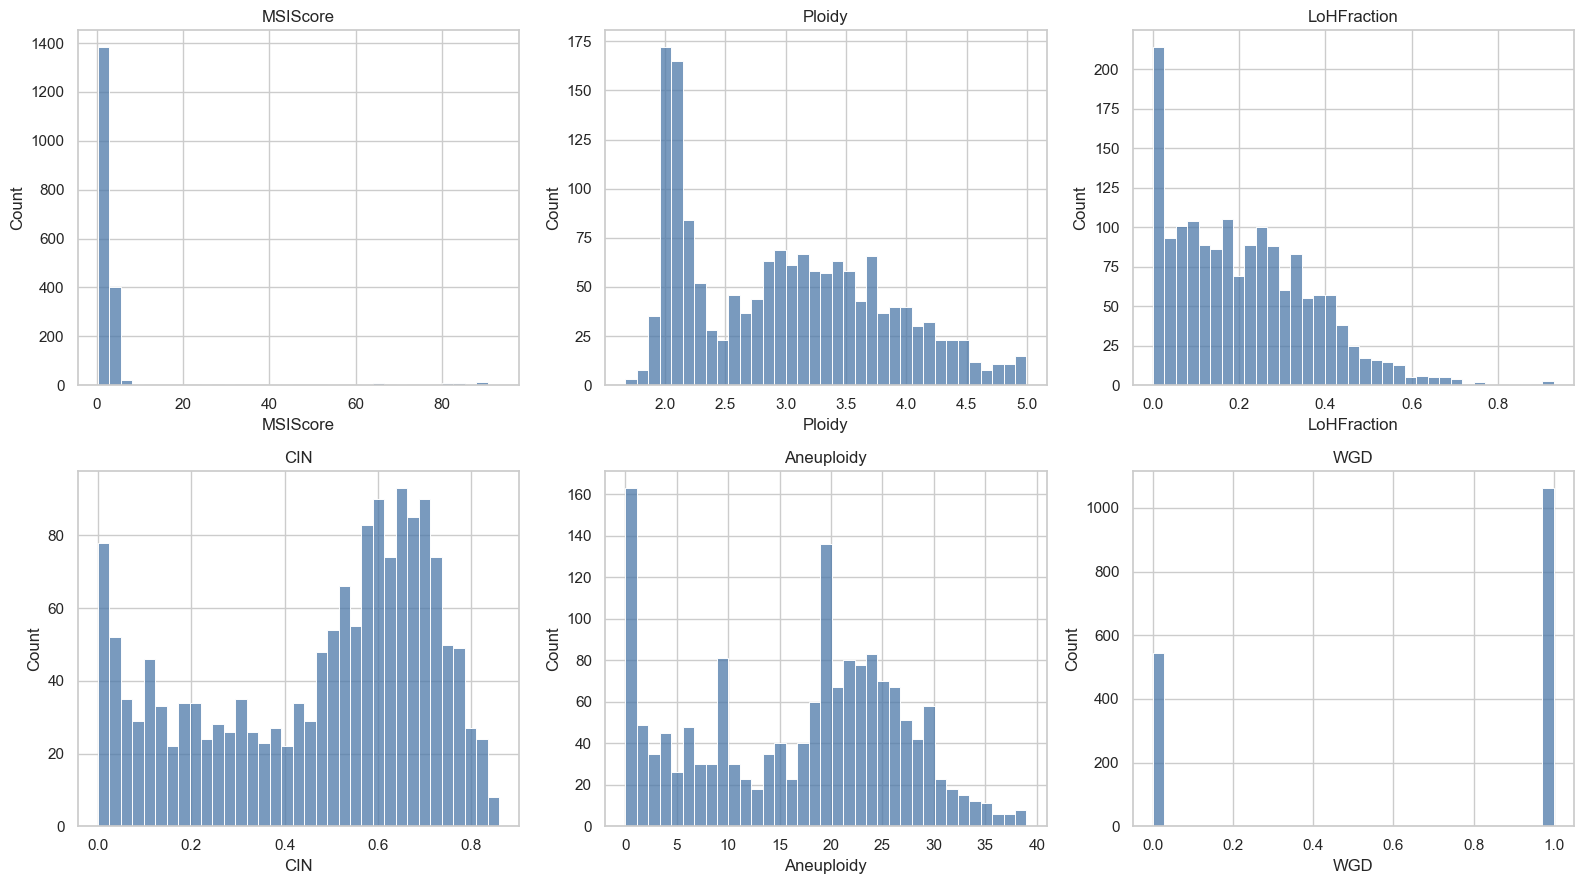

,review_flags,models
0,0,1774
1,1,154
2,2,1


In [3]:
metrics=['MSIScore','Ploidy','LoHFraction','CIN','Aneuploidy']
summary=pd.DataFrame({'missing_n':signatures.isna().sum(),'missing_pct':100*signatures.isna().mean(),'unique':signatures.nunique(dropna=True)})
display(summary)
display(signatures[metrics+['WGD']].describe().T)

fig,axes=plt.subplots(2,3,figsize=(16,9))
for ax,col in zip(axes.flat,metrics+['WGD']):
    sns.histplot(signatures[col].dropna(),bins=35,ax=ax,color='#4C78A8'); ax.set_title(col)
plt.tight_layout(); plt.show()

review=signatures[['model_id']].copy(); review_flags=[]
for col in metrics:
    q1,q3=signatures[col].quantile([0.25,0.75]); iqr=q3-q1
    flag=f'{col}_iqr_review'; review[flag]=(signatures[col]<q1-1.5*iqr)|(signatures[col]>q3+1.5*iqr); review_flags.append(flag)
review['n_review_flags']=review[review_flags].sum(axis=1)
display(review['n_review_flags'].value_counts().sort_index().rename_axis('review_flags').reset_index(name='models'))

### What this means for the project

An unusually high MSI score can point to mismatch-repair failure; unusually high ploidy can indicate many chromosome copies. Neither is automatically bad data. We keep the model and test whether a pair result changes when extreme genomic contexts are included or excluded.

## 3. Relationships between genome-wide measures

Whole-genome duplication, ploidy, chromosome instability, and aneuploidy describe related but different aspects of an abnormal genome. We inspect their overlap instead of combining them blindly.

,MSIScore,Ploidy,LoHFraction,CIN,Aneuploidy
MSIScore,1.00,-0.06,-0.08,-0.09,-0.06
Ploidy,-0.06,1.00,0.36,0.71,0.70
LoHFraction,-0.08,0.36,1.00,0.72,0.64
CIN,-0.09,0.71,0.72,1.00,0.84
Aneuploidy,-0.06,0.70,0.64,0.84,1.00


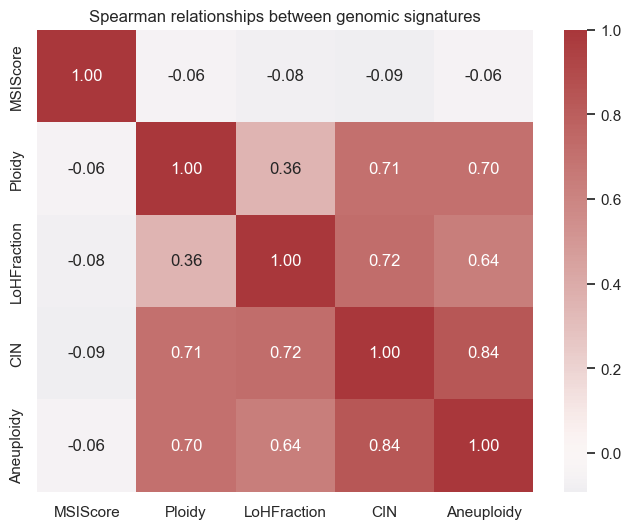

MSIScore                  Ploidy                     LoHFraction  \
       count median      mean  count    median      mean       count   
WGD                                                                    
0.0      545  2.160  7.492495    545  2.075887  2.107631         545   
1.0     1062  2.055  3.637053   1062  3.383440  3.447967        1062   

                          CIN                     Aneuploidy                    
       median      mean count    median      mean      count median       mean  
WGD                                                                             
0.0  0.061396  0.085260   545  0.156822  0.187002        545    4.0   5.521101  
1.0  0.266841  0.277971  1062  0.629850  0.609917       1062   23.0  22.386064

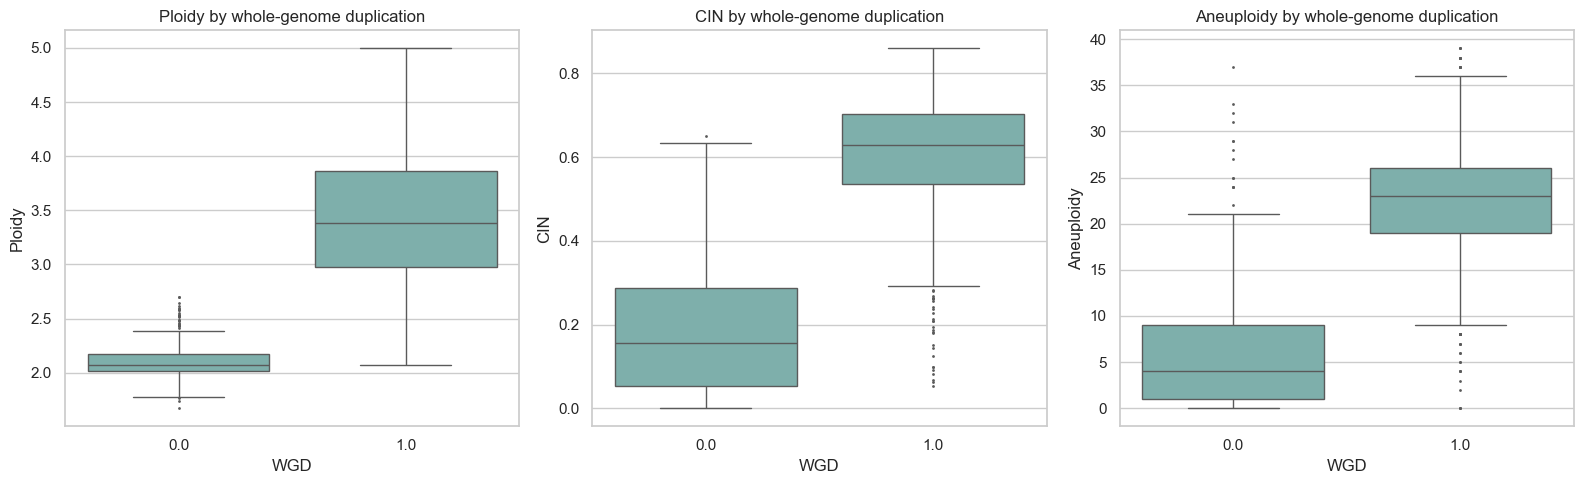

In [4]:
correlations=signatures[metrics].corr(method='spearman')
display(correlations.round(2))
plt.figure(figsize=(8,6)); sns.heatmap(correlations,annot=True,fmt='.2f',cmap='vlag',center=0); plt.title('Spearman relationships between genomic signatures'); plt.show()

wgd_comparison=signatures.groupby('WGD')[metrics].agg(['count','median','mean'])
display(wgd_comparison)
fig,axes=plt.subplots(1,3,figsize=(16,5))
for ax,col in zip(axes,['Ploidy','CIN','Aneuploidy']):
    sns.boxplot(data=signatures,x='WGD',y=col,ax=ax,color='#76B7B2',fliersize=1); ax.set_title(f'{col} by whole-genome duplication')
plt.tight_layout(); plt.show()

### What this means for the project

If a model has whole-genome duplication and ploidy near four, a gene with four copies may be close to the genome background rather than focally amplified. This context stops us from giving the same biological meaning to the same raw copy number in every model.

## 4. Lineage and overlap with pair-scoring routes

Some cancer types are more genomically unstable than others. We compare lineage medians and count models that also have mutation, copy-number, and CRISPR data.

In [5]:
context=signatures.merge(master[['model_id','oncotree_lineage','has_mutation_assay','has_absolute_copy_number','has_crispr_gene_effect']],on='model_id',how='left',validate='one_to_one')
lineage=context.groupby('oncotree_lineage').agg(models=('model_id','size'),MSIScore=('MSIScore','median'),Ploidy=('Ploidy','median'),LoHFraction=('LoHFraction','median'),WGD_pct=('WGD','mean'),CIN=('CIN','median'),Aneuploidy=('Aneuploidy','median')).sort_values('models',ascending=False)
lineage['WGD_pct']*=100
display(lineage)

overlap=pd.DataFrame([{
    'signature_models':len(context),
    'signature_and_mutation':int(context['has_mutation_assay'].eq(1).sum()),
    'signature_and_copy_number':int(context['has_absolute_copy_number'].eq(1).sum()),
    'signature_mutation_copy_number_CRISPR':int(context[['has_mutation_assay','has_absolute_copy_number','has_crispr_gene_effect']].eq(1).all(axis=1).sum()),
}])
display(overlap)

,models,MSIScore,Ploidy,LoHFraction,WGD_pct,CIN,Aneuploidy
oncotree_lineage,,,,,,,
Lymphoid,252,2.360,2.117253,0.057961,24.090909,0.176525,4.0
Lung,237,1.390,3.113752,0.324010,89.795918,0.649517,23.0
Skin,140,1.995,3.129490,0.187698,77.049180,0.580378,20.0
CNS/Brain,113,2.070,3.381081,0.184970,82.978723,0.602138,20.0
Head and Neck,94,2.105,3.227189,0.241961,80.952381,0.621638,22.0
Bowel,91,2.780,3.048546,0.216268,77.777778,0.569298,21.0
Esophagus/Stomach,90,2.130,3.224350,0.354852,86.842105,0.675373,23.5
Myeloid,84,2.120,2.159800,0.071566,29.166667,0.200810,6.0
Bone,84,2.005,2.583267,0.183955,56.521739,0.478014,17.0


,signature_models,signature_and_mutation,signature_and_copy_number,signature_mutation_copy_number_CRISPR
0,1929,1929,1607,948


### What this means for the project

A dependency pattern seen mainly in a highly unstable lineage may reflect that lineage's genome state. We will report the instability context and exact overlap rather than letting those models silently control the result.

## Decisions carried into cross-layer EDA

- Use genomic signatures as visible context or adjustment variables, not direct gene-pair evidence.
- Interpret absolute copy number relative to ploidy and whole-genome duplication; keep raw and context-adjusted views.
- Preserve MSI, LOH, CIN, aneuploidy, WGD, and ploidy separately before testing any combined instability summary.
- Carry mutation burden, copy-number burden, lineage, and signature review flags into sensitivity analyses.
- Restrict conditional-dependency comparisons to models with measured alteration and CRISPR data, and report the exact denominator.
- The next major stage can begin in `cross_layer`: mutation plus copy number for gene-A state, followed by gene-A state plus CRISPR dependency on gene B.